# Example: Downloading datasets with the `ecmwfapi`

**Note:** Any changes you make to this notebook will be lost once the page is closed or refreshed. Please download any files you would like to keep.

**Note:** The WASM-based version of the compression lab running inside JupyterLite has only been tested in recent Firefox browsers.

## Installing and configuring the `ecmwfapi` package

In [ ]:
import ecmwfapi

To run this example, you need an API key available from https://api.ecmwf.int/v1/key/, which looks as follows:

```json
{
    "url"   : "<ECMWF-API-URL>",
    "key"   : "<ECMWF-API-KEY>",
    "email" : "<ECMWF-API-EMAIL>"
}
```

Please enter these values to set the `ECMWF_API_*` environment variables in the next cell.

Please remember that you must keep your API key private and should not share a notebook that contains your API key.

In [ ]:
import os
os.environ["ECMWF_API_URL"] = "<ECMWF-API-URL>"
os.environ["ECMWF_API_KEY"] = "<ECMWF-API-KEY>"
os.environ["ECMWF_API_EMAIL"] = "<ECMWF-API-EMAIL>"

## Retrieving the dataset

The data, specified in a MARS request, can be retrieved from the Access MARS service with the following function:

In [ ]:
import re
import os


def mars_parser(req: str):

    if "WEBMARS_TARGET" in os.environ:
        target = os.environ["WEBMARS_TARGET"]
    else:
        m = re.search(r'\btar(g(e(t)?)?)?\s*=\s*([^\'",\s]+|"[^"]*"|\'[^\']*\')', req, re.I|re.M)
        if m is None:
            raise Exception("Cannot extract target")

        target = m.group(4)
        if target is None:
            raise Exception("Cannot extract target")

    if target[0] == target[-1]:
        if target[0] in ['"', "'"]:
            target = target[1:-1]

    c = ecmwfapi.ECMWFService('mars')
    c.execute(req, target)
    



Below we are gathering the necessary MARS requests to retrieve the Atmospheric model and Wave model data from the hplp experiment [https://apps.ecmwf.int/mars-catalogue/?class=rd&expver=hplp](https://apps.ecmwf.int/mars-catalogue/?class=rd&expver=hplp). 

In [ ]:
mars_request_ml = """
retrieve,
anoffset=9,
class=rd,
date=2020-07-21,
expver=hplp,
levelist=1,#/2/3/4/5/6/7/8/9/10/11/12/13/14/15/16/17/18/19/20/21/22/23/24/25/26/27/28/29/30/31/32/33/34/35/36/37/38/39/40/41/42/43/44/45/46/47/48/49/50/51/52/53/54/55/56/57/58/59/60/61/62/63/64/65/66/67/68/69/70/71/72/73/74/75/76/77/78/79/80/81/82/83/84/85/86/87/88/89/90/91/92/93/94/95/96/97/98/99/100/101/102/103/104/105/106/107/108/109/110/111/112/113/114/115/116/117/118/119/120/121/122/123/124/125/126/127/128/129/130/131/132/133/134/135/136/137,
levtype=ml,
param=75/76/129/130/131/132/133/135/138/152/155/203/246/247/248,
step=0,#/12/24/36/48/60/72/84/96/108/120/132/144/156/168/180/192/204/216/228/240,
stream=lwda,
time=00:00:00,
type=fc,
target="data_ml.grib"
"""

mars_request_pl = """
retrieve,
anoffset=9,
class=rd,
date=2020-07-21,
expver=hplp,
levelist=1,#/2/3/5/7/10/20/30/50/70/100/150/200/250/300/400/500/700/850/925/1000,
levtype=pl,
param=129.128/130.128/131/132/133.128/135.128/138.128/155.128/157.128,
step=0,#/12/24/36/48/60/72/84/96/108/120/132/144/156/168/180/192/204/216/228/240,
stream=lwda,
time=00:00:00,
type=fc,
target="data_pl.grib"
"""

mars_request_sfc = """
retrieve,
anoffset=9,
class=rd,
date=2020-07-21,
expver=hplp,
levtype=sfc,
param=1.228/8.128/9.128/20.3/29.228/31.128/32.128/33.128/34.128/35.128/36.128/37.128/38.128/39.128/40.128/41.128/42.128/44.128/45.128/47.128/49.128/50.128/57.128/58.128/59.128/78.128/79.128/89.228/90.228/129.128/131.151/132.151/136.128/137.128/139.128/141.128/142.128/143.128/144.128/145.128/146.128/147.128/148.128/151.128/159.128/164.128/165.128/166.128/167.128/168.128/169.128/170.128/172.128/175.128/176.128/177.128/178.128/179.128/180.128/181.128/182.128/183.128/186.128/187.128/188.128/189.128/195.128/196.128/197.128/198.128/201.128/202.128/205.128/206.128/208.128/209.128/210.128/211.128/212.128/213.128/216.228/217.228/218.228/219.228/220.228/221.228/228.128/229.128/230.128/231.128/232.128/235.128/236.128/238.128/243.128/244.128/245.128/251.228/260015/260121/260123,
step=0,#/12/24/36/48/60/72/84/96/108/120/132/144/156/168/180/192/204/216/228/240,
stream=lwda,
time=00:00:00,
type=fc,
target="data_sfc.grib"
"""

mars_request_wave = """
retrieve,
anoffset=9,
class=rd,
date=2020-07-21,
domain=g,
expver=hplp,
param=208.140/209.140/212.140/214.140/215.140/216.140/218.140/219.140/220.140/221.140/222.140/229.140/230.140/231.140/232.140/233.140/245.140/249.140,
step=0,#/12/24/36/48/60/72/84/96/108/120/132/144/156/168/180/192/204/216/228/240,
stream=lwwv,
time=00:00:00,
type=fc,
target="data_wave.grib"
"""

mars_request_ssd = """
retrieve,
anoffset=9,
channel=5/6/9,
class=rd,
date=2020-07-21,
expver=hplp,
ident=57,
instrument=207,
param=260510,
step=0,#/12/24/36/48/60,
stream=lwda,
time=00:00:00,
type=ssd,
target="data_ssd.grib"
"""


Calling the `mars_parser` functuion as below, one can download the data which will be saved to a new file as specified in `target` in the local directory.

In [ ]:
mars_parser(mars_request_pl)

## Dataset overview

In [1]:
import pandas as pd

# Define the data
data_ml = {
    "paramId": [75, 76, 129, 130, 133, 135, 138, 152, 155, 131, 132, 203, 246, 247, 248],
    "gridName": ["O400", "O400", "not_found", "not_found", "O400", "not_found", "not_found", "not_found", "not_found", "not_found", "not_found", "O400", "O400", "O400", "O400"],
    "gridType": ["reduced_gg", "reduced_gg", "sh", "sh", "reduced_gg", "sh", "sh", "sh", "sh", "sh", "sh", "reduced_gg", "reduced_gg", "reduced_gg", "reduced_gg"],
    "bitsPerValue": [0, 0, 16, 16, 0, 16, 16, 16, 16, 16, 16, 0, 0, 0, 0],
    "edition": [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
    "centre": ["ecmf"] * 15,
    "dateDate": ["20200721"] * 15,
    "dataType": ["fc"] * 15,
    "stepRange": [0] * 15,
    "typeOfLevel": ["hybrid"] * 10 + ["sh"] * 5,
    "level": [1] * 15,
    "shortName": ["crwc", "cswc", "z", "t", "q", "w", "vo", "lnsp", "d", "u", "v", "o3", "clwc", "ciwc", "cc"],
    "packingType": ["grid_ieee"] * 8 + ["spectral_ieee"] * 7,
    
}

# Create the DataFrame
df_ml = pd.DataFrame(data_ml)

# Print the DataFrame
display(df_ml)

,paramId,gridName,gridType,bitsPerValue,edition,centre,dateDate,dataType,stepRange,typeOfLevel,level,shortName,packingType
0,75,O400,reduced_gg,0,2,ecmf,20200721,fc,0,hybrid,1,crwc,grid_ieee
1,76,O400,reduced_gg,0,2,ecmf,20200721,fc,0,hybrid,1,cswc,grid_ieee
2,129,not_found,sh,16,2,ecmf,20200721,fc,0,hybrid,1,z,grid_ieee
3,130,not_found,sh,16,2,ecmf,20200721,fc,0,hybrid,1,t,grid_ieee
4,133,O400,reduced_gg,0,2,ecmf,20200721,fc,0,hybrid,1,q,grid_ieee
5,135,not_found,sh,16,2,ecmf,20200721,fc,0,hybrid,1,w,grid_ieee
6,138,not_found,sh,16,2,ecmf,20200721,fc,0,hybrid,1,vo,grid_ieee
7,152,not_found,sh,16,2,ecmf,20200721,fc,0,hybrid,1,lnsp,grid_ieee
8,155,not_found,sh,16,2,ecmf,20200721,fc,0,hybrid,1,d,spectral_ieee
9,131,not_found,sh,16,2,ecmf,20200721,fc,0,hybrid,1,u,spectral_ieee


In [2]:
data_pl = {
    "paramId": [129, 130, 133, 135, 138, 155, 131, 132, 157],
    "gridName": ["not_found", "not_found", "O400", "not_found", "not_found", "not_found", "not_found", "not_found", "not_found"],
    "gridType": ["sh", "sh", "reduced_gg", "sh", "sh", "sh", "sh", "sh", "sh"],
    "bitsPerValue": [16, 16, 16, 16, 16, 16, 16, 16, 16],
    "edition": [1] * 9,
    "centre": ["ecmf"] * 9,
    "dataDate": ["20200721"] * 9,
    "dataType": ["fc"] * 9,
    "stepRange": [0] * 9,
    "typeOfLevel": ["isobaricInhPa"] * 9,
    "level": [1] * 9,
    "shortName": ["z", "t", "q", "w", "vo", "d", "u", "v", "r"],
    "packingType": ["spectral_complex"] * 8 + ["spectral_complex"]
}

# Create the DataFrame
df_pl = pd.DataFrame(data_pl)

# Print the DataFrame
display(df_pl)

,paramId,gridName,gridType,bitsPerValue,edition,centre,dataDate,dataType,stepRange,typeOfLevel,level,shortName,packingType
0,129,not_found,sh,16,1,ecmf,20200721,fc,0,isobaricInhPa,1,z,spectral_complex
1,130,not_found,sh,16,1,ecmf,20200721,fc,0,isobaricInhPa,1,t,spectral_complex
2,133,O400,reduced_gg,16,1,ecmf,20200721,fc,0,isobaricInhPa,1,q,spectral_complex
3,135,not_found,sh,16,1,ecmf,20200721,fc,0,isobaricInhPa,1,w,spectral_complex
4,138,not_found,sh,16,1,ecmf,20200721,fc,0,isobaricInhPa,1,vo,spectral_complex
5,155,not_found,sh,16,1,ecmf,20200721,fc,0,isobaricInhPa,1,d,spectral_complex
6,131,not_found,sh,16,1,ecmf,20200721,fc,0,isobaricInhPa,1,u,spectral_complex
7,132,not_found,sh,16,1,ecmf,20200721,fc,0,isobaricInhPa,1,v,spectral_complex
8,157,not_found,sh,16,1,ecmf,20200721,fc,0,isobaricInhPa,1,r,spectral_complex


In [3]:
data_sfc = {
    'paramId': [
        228001, 8, 9, 3020, 228029, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 
        41, 42, 44, 45, 47, 49, 50, 57, 58, 59, 78, 79, 228089, 228090, 129, 
        151131, 151132, 136, 137, 139, 141, 142, 143, 144, 145, 146, 147, 148, 
        151, 159, 164, 165, 166, 167, 168, 169, 170, 172, 175, 176, 177, 178, 
        179, 180, 181, 182, 183, 186, 187, 188, 189, 195, 196, 197, 198, 201, 
        202, 205, 206, 208, 209, 210, 211, 212, 213, 228216, 228217, 228218, 
        228219, 228220, 228221, 228, 229, 230, 231, 232, 235, 236, 238, 243, 
        244, 245, 228251, 260015, 260121, 260123
    ],
    'gridName': ['O400'] * 101,
    'gridType': ['reduced_gg'] * 101,
    'bitsPerValue': [16] * 36 + [24]+ [16]* 60 + [24] + [0] * 3,
    'edition': [1] * 98 + [2] * 3,
    'centre': ['ecmf'] * 101,
    'dataDate': ['20200721'] * 101,
    'dataType': ['fc'] * 101,
    'stepRange': [0] * 101,
    'typeOfLevel': [
        'surface'] * 84 + [
        'depthBelowLandLayer'] * 17,
    'level': [
        0] * 84 + [0] * 17,
    'shortName': [
        'cin', 'sro', 'ssro', 'vis', 'i10fg', 'ci', 'asn', 'rsn', 'sst', 'istl1', 'istl2', 
        'istl3', 'istl4', 'swvl1', 'swvl2', 'swvl3', 'swvl4', 'es', 'smlt', 'dsrp', '10fg', 
        'lspf', 'uvb', 'par', 'cape', 'tclw', 'tciw', 'tcrw', 'tcsw', 'z', 'ocu', 'ocv', 
        'tcw', 'tcwv', 'stl1', 'sd', 'lsp', 'cp', 'sf', 'bld', 'sshf', 'slhf', 'chnk', 
        'msl', 'blh', 'tcc', '10u', '10v', '2t', '2d', 'ssrd', 'stl2', 'lsm', 'strd', 'ssr', 
        'str', 'tsr', 'ttr', 'ewss', 'nsss', 'e', 'stl3', 'lcc', 'mcc', 'hcc', 'sund', 'lgws', 
        'mgws', 'gwd', 'src', 'mx2t', 'mn2t', 'ro', 'tco3', 'tsrc', 'ttrc', 'ssrc', 'strc', 
        'tisr', 'vimd', 'fzra', 'ilspf', 'crr', 'lsrr', 'csfr', 'lssfr', 'tp', 'iews', 'inss', 
        'ishf', 'ie', 'skt', 'stl4', 'tsn', 'fal', 'fsr', 'flsr', 'pev', 'ptype', 'kx', 'totalx'
    ],
    'packingType': ['grid_ieee'] * 101
}

df_sfc = pd.DataFrame(data_sfc)
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(df_sfc)

,paramId,gridName,gridType,bitsPerValue,edition,centre,dataDate,dataType,stepRange,typeOfLevel,level,shortName,packingType
0,228001,O400,reduced_gg,16,1,ecmf,20200721,fc,0,surface,0,cin,grid_ieee
1,8,O400,reduced_gg,16,1,ecmf,20200721,fc,0,surface,0,sro,grid_ieee
2,9,O400,reduced_gg,16,1,ecmf,20200721,fc,0,surface,0,ssro,grid_ieee
3,3020,O400,reduced_gg,16,1,ecmf,20200721,fc,0,surface,0,vis,grid_ieee
4,228029,O400,reduced_gg,16,1,ecmf,20200721,fc,0,surface,0,i10fg,grid_ieee
5,31,O400,reduced_gg,16,1,ecmf,20200721,fc,0,surface,0,ci,grid_ieee
6,32,O400,reduced_gg,16,1,ecmf,20200721,fc,0,surface,0,asn,grid_ieee
7,33,O400,reduced_gg,16,1,ecmf,20200721,fc,0,surface,0,rsn,grid_ieee
8,34,O400,reduced_gg,16,1,ecmf,20200721,fc,0,surface,0,sst,grid_ieee
9,35,O400,reduced_gg,16,1,ecmf,20200721,fc,0,surface,0,istl1,grid_ieee


In [4]:
data_ssd = {
    "paramId": [260510, 260510, 260510],
    "gridName": ["O400", "O400", "O400"],
    "gridType": ["reduced_gg", "reduced_gg", "reduced_gg"],
    "bitsPerValue": [0, 0, 0],
    "edition": [2, 2, 2],
    "centre": ["ecmf", "ecmf", "ecmf"],
    "dateDat": ["20200721", "20200721", "20200721"],
    "dataType": ["ssd", "ssd", "ssd"],
    "stepRange": [0, 0, 0],
    "shortName": ["clbt", "clbt", "clbt"],
    "packingType": ["grid_ieee", "grid_ieee", "grid_ieee"]
}

df_ssd = pd.DataFrame(data_ssd)


display(df_ssd)

,paramId,gridName,gridType,bitsPerValue,edition,centre,dateDat,dataType,stepRange,shortName,packingType
0,260510,O400,reduced_gg,0,2,ecmf,20200721,ssd,0,clbt,grid_ieee
1,260510,O400,reduced_gg,0,2,ecmf,20200721,ssd,0,clbt,grid_ieee
2,260510,O400,reduced_gg,0,2,ecmf,20200721,ssd,0,clbt,grid_ieee


In [5]:
data_wave = {
    'paramId': [140208, 140209, 140212, 140214, 140215, 140216, 140218, 140219, 140220, 140221, 140222, 140229, 140230, 140231, 140232, 140233, 140245, 140249],
    'gridName': ['not_found'] * 18,
    'gridType': ['reduced_ll'] * 18,
    'bitsPerValue': [16] * 18,
    'edition': [1] * 18,
    'centre': ['ecmf'] * 18,
    'dataDate': ['20200721'] * 18,
    'dataType': ['fc'] * 18,
    'stepRange': [0] * 18,
    'typeOfLevel': ['meanSea'] * 15 + ['heightAboveGround'] * 3,
    'level': [0] * 15 + [10] * 3,
    'shortName': ['wstar', 'rhoao', 'phioc', 'tauoc', 'ust', 'vst', 'hmax', 'wmb', 'mp1', 'mp2', 'wdw', 'swh', 'mwd', 'pp1d', 'mwp', 'cdww', 'wind', 'dwi'],
    'packingType': ['grid_simple'] * 18
}


df_wave = pd.DataFrame(data_wave)


display(df_wave)

,paramId,gridName,gridType,bitsPerValue,edition,centre,dataDate,dataType,stepRange,typeOfLevel,level,shortName,packingType
0,140208,not_found,reduced_ll,16,1,ecmf,20200721,fc,0,meanSea,0,wstar,grid_simple
1,140209,not_found,reduced_ll,16,1,ecmf,20200721,fc,0,meanSea,0,rhoao,grid_simple
2,140212,not_found,reduced_ll,16,1,ecmf,20200721,fc,0,meanSea,0,phioc,grid_simple
3,140214,not_found,reduced_ll,16,1,ecmf,20200721,fc,0,meanSea,0,tauoc,grid_simple
4,140215,not_found,reduced_ll,16,1,ecmf,20200721,fc,0,meanSea,0,ust,grid_simple
5,140216,not_found,reduced_ll,16,1,ecmf,20200721,fc,0,meanSea,0,vst,grid_simple
6,140218,not_found,reduced_ll,16,1,ecmf,20200721,fc,0,meanSea,0,hmax,grid_simple
7,140219,not_found,reduced_ll,16,1,ecmf,20200721,fc,0,meanSea,0,wmb,grid_simple
8,140220,not_found,reduced_ll,16,1,ecmf,20200721,fc,0,meanSea,0,mp1,grid_simple
9,140221,not_found,reduced_ll,16,1,ecmf,20200721,fc,0,meanSea,0,mp2,grid_simple


## Destinguishing between grid point and spherical harmonics data

Regridding the **model level** spherical harmonics data onto an O400 grid leads to a segmentation fault currently.

In [ ]:
param_ids_reduced_gg = [param for param, grid in zip(data_ml['paramId'], data_ml['gridType']) if grid == "reduced_gg"]
param_ids_sh = [param for param, grid in zip(data_ml['paramId'], data_ml['gridType']) if grid == "sh"]


mars_request_ml_reduced_gg = f"""
retrieve,
anoffset=9,
class=rd,
date=2020-07-21,
expver=hplp,
levelist=1,#/2/3/4/5/6/7/8/9/10/11/12/13/14/15/16/17/18/19/20/21/22/23/24/25/26/27/28/29/30/31/32/33/34/35/36/37/38/39/40/41/42/43/44/45/46/47/48/49/50/51/52/53/54/55/56/57/58/59/60/61/62/63/64/65/66/67/68/69/70/71/72/73/74/75/76/77/78/79/80/81/82/83/84/85/86/87/88/89/90/91/92/93/94/95/96/97/98/99/100/101/102/103/104/105/106/107/108/109/110/111/112/113/114/115/116/117/118/119/120/121/122/123/124/125/126/127/128/129/130/131/132/133/134/135/136/137,
levtype=ml,
param={"/".join(map(str, param_ids_reduced_gg))},
step=0,#/12/24/36/48/60/72/84/96/108/120/132/144/156/168/180/192/204/216/228/240,
stream=lwda,
time=00:00:00,
type=fc,
target="data_ml_reduced_gg.grib"
"""

mars_request_ml_sh = f"""
retrieve,
anoffset=9,
class=rd,
date=2020-07-21,
expver=hplp,
levelist=1,#/2/3/4/5/6/7/8/9/10/11/12/13/14/15/16/17/18/19/20/21/22/23/24/25/26/27/28/29/30/31/32/33/34/35/36/37/38/39/40/41/42/43/44/45/46/47/48/49/50/51/52/53/54/55/56/57/58/59/60/61/62/63/64/65/66/67/68/69/70/71/72/73/74/75/76/77/78/79/80/81/82/83/84/85/86/87/88/89/90/91/92/93/94/95/96/97/98/99/100/101/102/103/104/105/106/107/108/109/110/111/112/113/114/115/116/117/118/119/120/121/122/123/124/125/126/127/128/129/130/131/132/133/134/135/136/137,
levtype=ml,
param={"/".join(map(str, param_ids_sh))},
step=0,#/12/24/36/48/60/72/84/96/108/120/132/144/156/168/180/192/204/216/228/240,
grid=O400,
stream=lwda,
time=00:00:00,
type=fc,
target="data_ml_sh_O400.grib"
"""
#mars_parser(mars_request_ml_reduced_gg)
#mars_parser(mars_request_ml_sh)

In [ ]:
param_ids_reduced_gg = [param for param, grid in zip(data_pl['paramId'], data_pl['gridType']) if grid == "reduced_gg"]
param_ids_sh = [param for param, grid in zip(data_pl['paramId'], data_pl['gridType']) if grid == "sh"]


mars_request_pl_reduced_gg = f"""
retrieve,
anoffset=9,
class=rd,
date=2020-07-21,
expver=hplp,
levelist=1,#/2/3/5/7/10/20/30/50/70/100/150/200/250/300/400/500/700/850/925/1000,
levtype=pl,
param={"/".join(map(str, param_ids_reduced_gg))},
step=0,#/12/24/36/48/60/72/84/96/108/120/132/144/156/168/180/192/204/216/228/240,
stream=lwda,
time=00:00:00,
type=fc,
target="data_pl_reduced_gg.grib"
"""

mars_request_pl_sh = f"""
retrieve,
anoffset=9,
class=rd,
date=2020-07-21,
expver=hplp,
levelist=1,#/2/3/5/7/10/20/30/50/70/100/150/200/250/300/400/500/700/850/925/1000,
levtype=pl,
param={"/".join(map(str, param_ids_sh))},
step=0,#/12/24/36/48/60/72/84/96/108/120/132/144/156/168/180/192/204/216/228/240,
stream=lwda,
grid=O400,
time=00:00:00,
type=fc,
target="data_pl_sh_O400.grib"
"""

#mars_parser(mars_request_pl_reduced_gg)
#mars_parser(mars_request_pl_sh)

In [ ]:
mars_request_sfc_new = f"""
retrieve,
anoffset=9,
class=rd,
date=2020-07-21,
expver=hplp,
levtype=sfc,
param={"/".join(map(str, data_sfc['paramId']))},
step=0,#/12/24/36/48/60/72/84/96/108/120/132/144/156/168/180/192/204/216/228/240,
stream=lwda,
time=00:00:00,
type=fc,
target="data_sfc_new.grib"
"""

#mars_parser(mars_request_sfc_new)

In [ ]:
mars_request_wave_new = f"""
retrieve,
anoffset=9,
class=rd,
date=2020-07-21,
domain=g,
expver=hplp,
param= {"/".join(map(str, data_wave['paramId']))},
step=0,#/12/24/36/48/60/72/84/96/108/120/132/144/156/168/180/192/204/216/228/240,
stream=lwwv,
time=00:00:00,
type=fc,
target="data_wave_test.grib"
"""
#mars_parser(mars_request_wave_new)

For the `ssd` fields, please take the original request from above. 

## Plotting the dataset


We can open the dataset with `earthkit.data.from_source` and then plot it with `earthkit.plots.point_cloud`. 
The following works fine for all data **except sfc**, where it leads to the error:

`DatasetBuildError: key present and new value is different: key='depthBelowLandLayer' value=Variable(dimensions=('depthBelowLandLayer',), data=array([0.])) new_value=Variable(dimensions=('depthBelowLandLayer',), data=array([7.]))
`

For the **ml** and **pl** data, loading only works fine when loading the reduced_gg and sh parts separately.

In [6]:
import earthkit
print(earthkit.__version__)


data = earthkit.data.from_source("file", "data_ml_reduced_gg.grib")
da = data[0:]
da_x = da.to_xarray()
display(da_x)
data_vars = list(da_x.data_vars)


0.6.2


<xarray.Dataset>
Dimensions:     (time: 1, step: 1, hybrid: 1, values: 654400)
Coordinates:
  * time        (time) datetime64[ns] 2020-07-21
  * step        (step) timedelta64[ns] 00:00:00
  * hybrid      (hybrid) float64 1.0
    latitude    (values) float64 ...
    longitude   (values) float64 ...
    valid_time  (time, step) datetime64[ns] ...
Dimensions without coordinates: values
Data variables:
    crwc        (time, step, hybrid, values) float32 ...
    cswc        (time, step, hybrid, values) float32 ...
    q           (time, step, hybrid, values) float32 ...
    o3          (time, step, hybrid, values) float32 ...
    clwc        (time, step, hybrid, values) float32 ...
    ciwc        (time, step, hybrid, values) float32 ...
    cc          (time, step, hybrid, values) float32 ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2024-09-20T16:40 GRIB to CDM+CF via cfgrib-0.9.1...

crwc
the minimal and the maximal values are both equal to 0.0, therefore we omit the plot.
cswc
the minimal and the maximal values are both equal to 0.0, therefore we omit the plot.
q
Range of values: 1.2824231134800357e-06 to 3.1715526347397827e-06


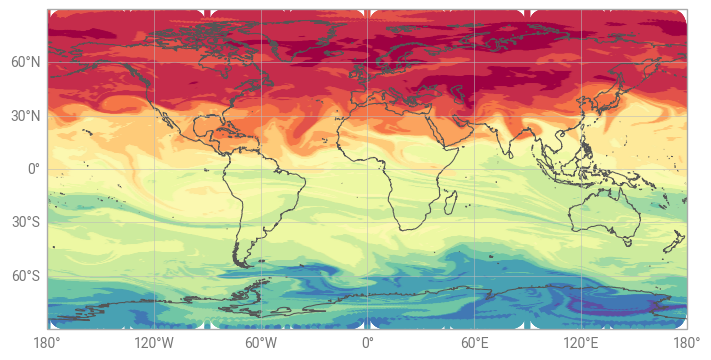

o3
Range of values: 1.0338087008676666e-07 to 9.917657735059038e-06


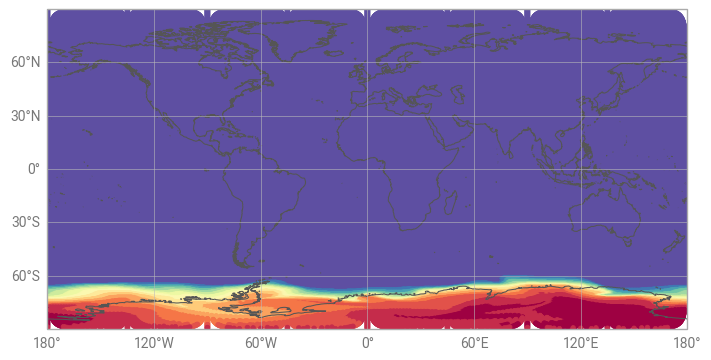

clwc
the minimal and the maximal values are both equal to 0.0, therefore we omit the plot.
ciwc
the minimal and the maximal values are both equal to 0.0, therefore we omit the plot.
cc
the minimal and the maximal values are both equal to 0.0, therefore we omit the plot.


In [7]:
import earthkit.plots as ekp
import numpy as np

for var_name in data_vars:
    print(var_name)
    variable_data = da_x[var_name]

    min_value = variable_data.min().item()
    max_value = variable_data.max().item()

    if min_value == max_value:
        print(f"the minimal and the maximal values are both equal to {min_value}, therefore we omit the plot.")

    else:
        print(f"Range of values: {min_value} to {max_value}")
        m = ekp.Map()
        m.point_cloud(da_x, x='longitude', y='latitude', z=var_name, 
                      levels=np.linspace(min_value, max_value,16), colors="Spectral_r")
        
        m.coastlines()
        m.gridlines()
        #m.legend() TODO: The legend causes an error for some variables, e.g. q (param=133)
        
        m.show()

In [8]:
import dask
import xarray as xr
import fcbench
fcbench.codecs.preload()

dask.config.set(array__chunk_size="32MiB");

# TODO: remove this code
try:
    import pyodide_js
except ImportError:
    pass
else:
    with open("utils.py") as up:
        await pyodide_js.loadPackagesFromImports(up.read())
import utils

Loaded the fcbench.codecs.Round codec ...
Loaded the fcbench.codecs.Sz3 codec ...
Loaded the fcbench.codecs.Identity codec ...
Loaded the fcbench.codecs.BitRound codec ...
Loaded the fcbench.codecs.Zlib codec ...
Loaded the fcbench.codecs.FixedOffsetScale codec ...
Loaded the fcbench.codecs.UniformNoise codec ...
Loaded the fcbench.codecs.Log codec ...
Loaded the fcbench.codecs.Reinterpret codec ...
Loaded the fcbench.codecs.Zstd codec ...
Loaded the fcbench.codecs.LinearQuantize codec ...
Loaded the fcbench.codecs.Zfp codec ...


Applying the simple compressor works fine everywhere except for the **wave** data, where it leads to a `RuntimeError: WASM guest raised an error`.

It has not been tested yet on the **sfc** data.

In [9]:
simple_compressor = []
da_simple = {}
stats_simple = {}

for d in da_x.data_vars:
    simple_compressor.append([fcbench.codecs.LinearQuantize(bits=4, dtype=str(da_x[d].dtype))])
    
    da_simple[d], stats_simple[d] = fcbench.compressor.compute_dataarray_compress_decompress(
        da_x[d], simple_compressor[-1] 
    )
    
    print(f"{da_x[d].attrs.get('long_name', d)}" + ":")
    
    display(utils.format_compress_stats(simple_compressor[-1], stats_simple[d]))


Specific rain water content:


,compression ratio [raw B / enc B],encode throughput [raw GB/s],decode throughput [raw GB/s],encode instructions [#/B],decode instructions [#/B]
Codec,,,,,
"fcbench.codecs.LinearQuantize(dtype='f32', bits=4)",4.0,0.08,0.03,3.9,2.0


Specific snow water content:


,compression ratio [raw B / enc B],encode throughput [raw GB/s],decode throughput [raw GB/s],encode instructions [#/B],decode instructions [#/B]
Codec,,,,,
"fcbench.codecs.LinearQuantize(dtype='f32', bits=4)",4.0,0.09,0.03,3.9,2.0


Specific humidity:


...

,compression ratio [raw B / enc B],encode throughput [raw GB/s],decode throughput [raw GB/s],encode instructions [#/B],decode instructions [#/B]
Codec,,,,,
"fcbench.codecs.LinearQuantize(dtype='f32', bits=4)",4.0,0.09,0.03,3.9,2.0


Specific cloud ice water content:


,compression ratio [raw B / enc B],encode throughput [raw GB/s],decode throughput [raw GB/s],encode instructions [#/B],decode instructions [#/B]
Codec,,,,,
"fcbench.codecs.LinearQuantize(dtype='f32', bits=4)",4.0,0.08,0.03,3.9,2.0


Fraction of cloud cover:


,compression ratio [raw B / enc B],encode throughput [raw GB/s],decode throughput [raw GB/s],encode instructions [#/B],decode instructions [#/B]
Codec,,,,,
"fcbench.codecs.LinearQuantize(dtype='f32', bits=4)",4.0,0.09,0.03,3.9,2.0


In [10]:
def compute_relative_errors(da_compressed, da):
    da_error = da_compressed - da

    norm_L1_error = np.abs(da_error).sum().values
    norm_L2_error = np.sqrt((da_error**2).sum().values)
    norm_Linf_error = np.abs(da_error).max().values

    norm_L1_original = np.abs(da).sum().values
    norm_L2_original = np.sqrt((da**2).sum().values)
    norm_Linf_original = np.abs(da).max().values

    relative_error_L1 = norm_L1_error / norm_L1_original
    relative_error_L2 = norm_L2_error / norm_L2_original
    relative_error_Linf = norm_Linf_error / norm_Linf_original

    return {
        "Relative_Error_L1": relative_error_L1,
        "Relative_Error_L2": relative_error_L2,
        "Relative_Error_Linf": relative_error_Linf,
    }

In [11]:
errors_simple = {}
da_simple_error = []
for d in da_x.data_vars:
    errors_simple[d] = compute_relative_errors(da_simple[d], da_x[d])
    with xr.set_options(keep_attrs=True):
        da_simple_error = da_simple[d] - da_x[d]
    

/var/folders/yk/ynndwgjs2sjc8ffm43b35lxc0000gn/T/ipykernel_75122/4000104554.py:12: RuntimeWarning: invalid value encountered in divide
  relative_error_L1 = norm_L1_error / norm_L1_original
/var/folders/yk/ynndwgjs2sjc8ffm43b35lxc0000gn/T/ipykernel_75122/4000104554.py:13: RuntimeWarning: invalid value encountered in scalar divide
  relative_error_L2 = norm_L2_error / norm_L2_original
/var/folders/yk/ynndwgjs2sjc8ffm43b35lxc0000gn/T/ipykernel_75122/4000104554.py:14: RuntimeWarning: invalid value encountered in divide
  relative_error_Linf = norm_Linf_error / norm_Linf_original
/var/folders/yk/ynndwgjs2sjc8ffm43b35lxc0000gn/T/ipykernel_75122/4000104554.py:12: RuntimeWarning: invalid value encountered in divide
  relative_error_L1 = norm_L1_error / norm_L1_original
/var/folders/yk/ynndwgjs2sjc8ffm43b35lxc0000gn/T/ipykernel_75122/4000104554.py:13: RuntimeWarning: invalid value encountered in scalar divide
  relative_error_L2 = norm_L2_error / norm_L2_original
/var/folders/yk/ynndwgjs2sjc8f

In [12]:
data = []

compressors = {
    "Linear Quantization": (errors_simple, stats_simple),
    #"ZFP": (errors_transform, stats_transform),
    #"SZ3": (errors_predict, stats_predict),
    #"Bit Rounding": (errors_rounding, stats_rounding),
}

for compressor_name, (errors, stats) in compressors.items():
    for variable, error_data in errors.items():
        row = {
            "Compressor": compressor_name,
            "Variable": variable,
            "Compression Ratio [raw B / enc B]": round(
                stats[variable][0].decoded_bytes / stats[variable][-1].encoded_bytes,
                2,
            ),
            "L1 Error": error_data.get("Relative_Error_L1", None),
            "L2 Error": error_data.get("Relative_Error_L2", None),
            "Linf Error": error_data.get("Relative_Error_Linf", None),
            "Encode Instructions [# / raw B]": round(
                sum(s.encode_instructions for s in stats[variable])
                / stats[variable][0].decoded_bytes,
                1,
            ),
            "Decode Instructions [# / raw B]": round(
                sum(s.decode_instructions for s in stats[variable])
                / stats[variable][0].decoded_bytes,
                1,
            ),
            "Encode Throughput [raw GB / s]": round(
                1e-9
                * stats[variable][0].decoded_bytes
                / sum(
                    s.encode_timing.secs + s.encode_timing.nanos * 1e-9
                    for s in stats[variable]
                ),
                2,
            ),
            "Decode Throughput [raw GB / s]": round(
                1e-9
                * stats[variable][0].decoded_bytes
                / sum(
                    s.decode_timing.secs + s.decode_timing.nanos * 1e-9
                    for s in stats[variable]
                ),
                2,
            ),
        }
        data.append(row)


df = pd.DataFrame(data)
df

,Compressor,Variable,Compression Ratio [raw B / enc B],L1 Error,L2 Error,Linf Error,Encode Instructions [# / raw B],Decode Instructions [# / raw B],Encode Throughput [raw GB / s],Decode Throughput [raw GB / s]
0,Linear Quantization,crwc,4.0,NaN,NaN,NaN,3.9,2.0,0.08,0.03
1,Linear Quantization,cswc,4.0,NaN,NaN,NaN,3.9,2.0,0.09,0.03
2,Linear Quantization,q,4.0,0.026964,0.030722,0.03971,9.1,2.0,0.02,0.03
3,Linear Quantization,o3,4.0,0.178882,0.074269,0.06597,9.1,2.0,0.02,0.03
4,Linear Quantization,clwc,4.0,NaN,NaN,NaN,3.9,2.0,0.09,0.03
5,Linear Quantization,ciwc,4.0,NaN,NaN,NaN,3.9,2.0,0.08,0.03
6,Linear Quantization,cc,4.0,NaN,NaN,NaN,3.9,2.0,0.09,0.03


The ones with `NaN` are actually 0.0 everywhere, so we should omit the error computation here.

the minimal and the maximal values are both equal to 0.0, therefore we omit the plot.
the minimal and the maximal values are both equal to 0.0, therefore we omit the plot.
Range of values: -1.2594182408065535e-07 to 0.0


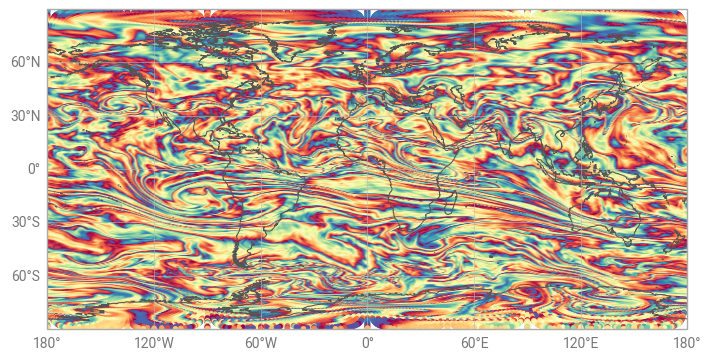

Range of values: -6.542695700773038e-07 to 0.0


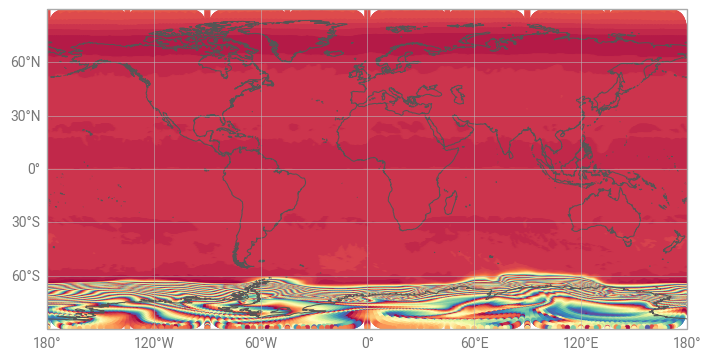

the minimal and the maximal values are both equal to 0.0, therefore we omit the plot.
the minimal and the maximal values are both equal to 0.0, therefore we omit the plot.
the minimal and the maximal values are both equal to 0.0, therefore we omit the plot.


In [13]:
import earthkit.plots as ekp
import numpy as np

for var_name in data_vars:
    variable_data = da_simple[var_name]-da_x[var_name]

    min_value = variable_data.min().item()
    max_value = variable_data.max().item()

    if min_value == max_value:
        print(f"the minimal and the maximal values are both equal to {min_value}, therefore we omit the plot.")

    else:
        print(f"Range of values: {min_value} to {max_value}")
        m = ekp.Map()
        m.point_cloud(variable_data, x='longitude', y='latitude',# z=var_name, 
                      levels=np.linspace(min_value, max_value,48), colors="Spectral_r")
        
        m.coastlines()
        m.gridlines()
        #m.legend() TODO: The legend causes an error for some variables, e.g. q (param=133)
        
        m.show()

In [ ]:
transform_compressor = []
da_transform = {}
stats_transform = {}

# TODO shift to positive values like in https://github.com/climet-eu/compression-lab-notebooks/issues/8

for d in da_x.data_vars:
    transform_compressor.append(
        [
            fcbench.codecs.Log(),
            fcbench.codecs.Zfp(mode="fixed-accuracy", tolerance=1e-3),
        ]
    )
    
    da_transform[d], stats_transform[d] = (
        fcbench.compressor.compute_dataarray_compress_decompress(
            da_x[d], transform_compressor[-1]
        )
    )
    
    print(f"{da_x[d].attrs.get('long_name', d)}" + ":")
    
    display(utils.format_compress_stats(transform_compressor[-1], stats_transform[d]))



The above error is probably related to negative values.

In [ ]:
predict_compressor = []
da_predict = {}
stats_predict = {}

for d in da_x.data_vars:
    predict_compressor.append([fcbench.codecs.Sz3(eb_mode="rel", eb_rel=1e-3)])
    
    da_predict[d], stats_predict[d] = (
        fcbench.compressor.compute_dataarray_compress_decompress(
            da_x[d], predict_compressor[-1]
        )
    )
    
    print(f"{da_x[d].attrs.get('long_name', d)}" + ":")
    
    display(utils.format_compress_stats(predict_compressor[-1], stats_predict[d]))



In [ ]:
rounding_compressor = []
da_rounding = {}
stats_rounding = {}

for d in da_x.data_vars:
    rounding_compressor.append(
        [fcbench.codecs.BitRound(keepbits=6), fcbench.codecs.Zlib(level=9)]
    )
    
    da_rounding[d], stats_rounding[d] = (
        fcbench.compressor.compute_dataarray_compress_decompress(
            da_x[d], rounding_compressor[-1]
        )
    )
    
    print(f"{da_x[d].attrs.get('long_name', d)}" + ":")
    
    display(utils.format_compress_stats(rounding_compressor[-1], stats_rounding[d]))

